**02452** *Machine Learning intelligent systems classs*, Technical University of Denmark



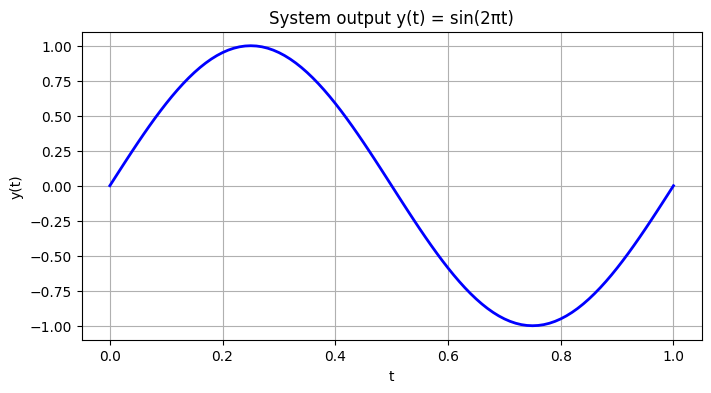

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Plot y(t) = sin(2πt), with t = 0:0.01:1
t = np.arange(0, 1.01, 0.01)  # from 0 to 1 with step 0.01
y = np.sin(2 * np.pi * t)

plt.figure(figsize=(8, 4))
plt.plot(t, y, 'b-', linewidth=2)
plt.title('System output y(t) = sin(2πt)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

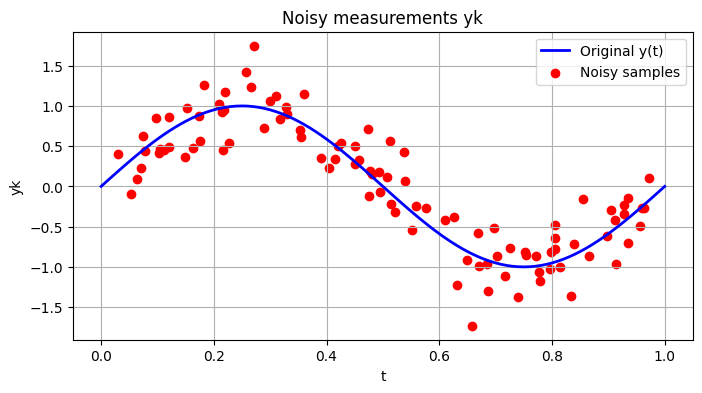

In [2]:
# 2. Generate and plot yk with noise
L = 100
sigma2 = 0.09
sigma = np.sqrt(sigma2)

tk = np.random.uniform(0, 1, L)   # sample times uniformly in [0,1]
nk = np.random.normal(0, sigma, L) # Gaussian noise
yk = np.sin(2 * np.pi * tk) + nk   # noisy measurements

plt.figure(figsize=(8, 4))
plt.plot(t, y, 'b-', linewidth=2, label='Original y(t)')
plt.scatter(tk, yk, c='r', marker='o', label='Noisy samples')
plt.title('Noisy measurements yk')
plt.xlabel('t')
plt.ylabel('yk')
plt.legend()
plt.grid(True)
plt.show()

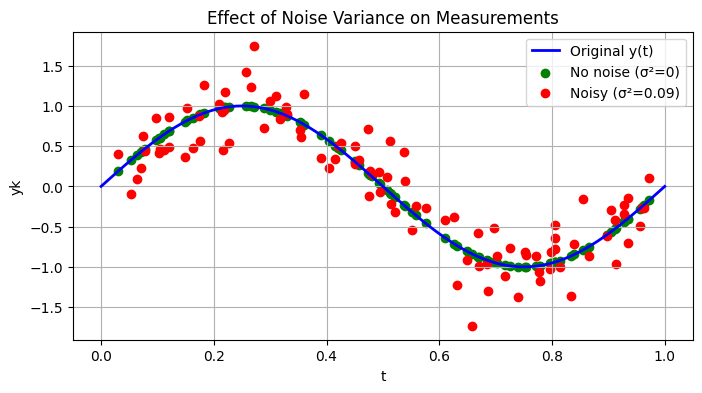

In [3]:
# 3. Effect of increasing noise variance (σ² = 0 vs 0.09)
yk0 = np.sin(2 * np.pi * tk)  # no noise case

plt.figure(figsize=(8, 4))
plt.plot(t, y, 'b-', linewidth=2, label='Original y(t)')
plt.scatter(tk, yk0, c='g', marker='o', label='No noise (σ²=0)')
plt.scatter(tk, yk, c='r', marker='o', label='Noisy (σ²=0.09)')
plt.title('Effect of Noise Variance on Measurements')
plt.xlabel('t')
plt.ylabel('yk')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# ----------------------------
# Parameters
# ----------------------------
L = 100            # number of training samples
sigma2 = 0.09      # noise variance
M = 3              # polynomial order (degree)
eta = 0.1          # learning rate
iterations = 3000  # gradient descent iterations
rng = np.random.default_rng(42)

# ----------------------------
# Data generation
# ----------------------------
t_train = np.linspace(0, 1, L)
y_true_train = np.sin(2 * np.pi * t_train)
noise = rng.normal(loc=0.0, scale=np.sqrt(sigma2), size=L)
y_train = y_true_train + noise

def design_matrix(t, degree):
    """Builds design matrix with columns [1, t, t^2, ..., t^M]."""
    return np.vstack([t**j for j in range(degree+1)]).T

X = design_matrix(t_train, M)

# ----------------------------
# Gradient descent
# ----------------------------
W = np.zeros(M+1)            # initialize weights
mse_history = np.zeros(iterations)

for it in range(iterations):
    y_pred = X.dot(W)
    error = y_pred - y_train
    grad = (2.0 / L) * X.T.dot(error)
    W -= eta * grad
    mse_history[it] = np.mean(error**2)

print("Learned weights W:", np.round(W, 6))
print("Final training MSE:", np.round(mse_history[-1], 6))



Learned weights W: [ 0.923502 -1.08204  -2.575222  1.842443]
Final training MSE: 0.230524


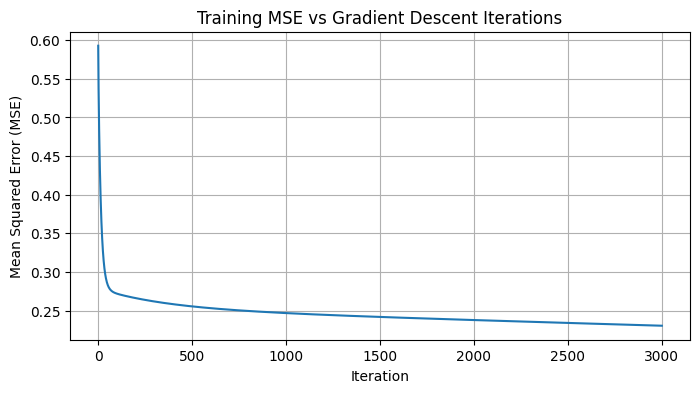

In [7]:
# ----------------------------
# Plot 1: MSE evolution
# ----------------------------
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, iterations+1), mse_history)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Training MSE vs Gradient Descent Iterations")
plt.grid(True)
plt.show()

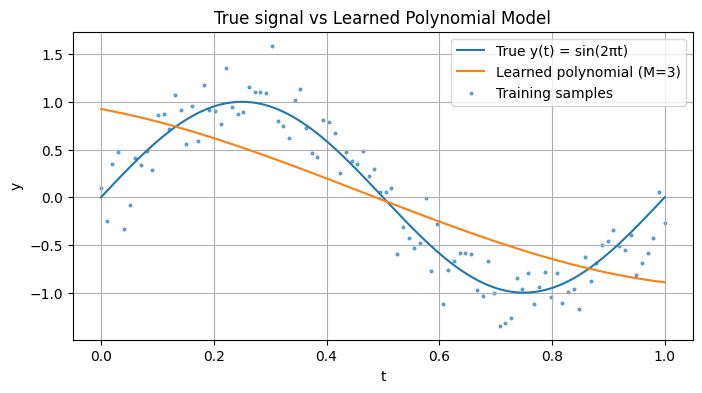

In [8]:
# ----------------------------
# Plot 2: True vs learned model
# ----------------------------
t_test = np.arange(0.0, 1.0+0.01, 0.01)
X_test = design_matrix(t_test, M)
y_hat_test = X_test.dot(W)
y_true_test = np.sin(2 * np.pi * t_test)

plt.figure(figsize=(8,4))
plt.plot(t_test, y_true_test, label="True y(t) = sin(2πt)")
plt.plot(t_test, y_hat_test, label="Learned polynomial (M=3)")
plt.scatter(t_train, y_train, s=15, label="Training samples", marker='.', alpha=0.6)
plt.xlabel("t")
plt.ylabel("y")
plt.title("True signal vs Learned Polynomial Model")
plt.legend()
plt.grid(True)
plt.show()

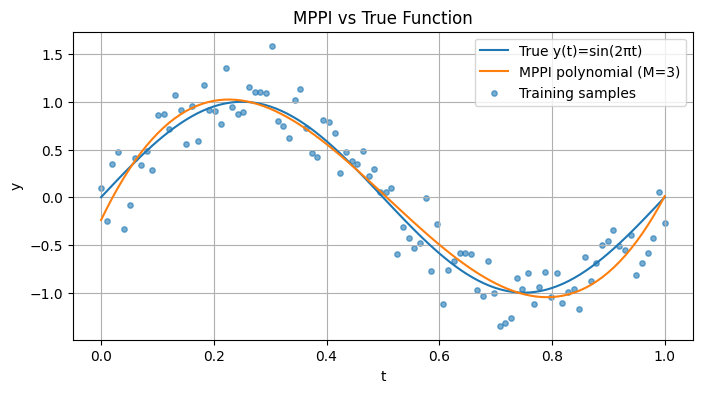

Weights from MPPI: [ -0.2392  12.3402 -35.0695  22.9795]
Training RMSE (L=100): 0.2401228428955424


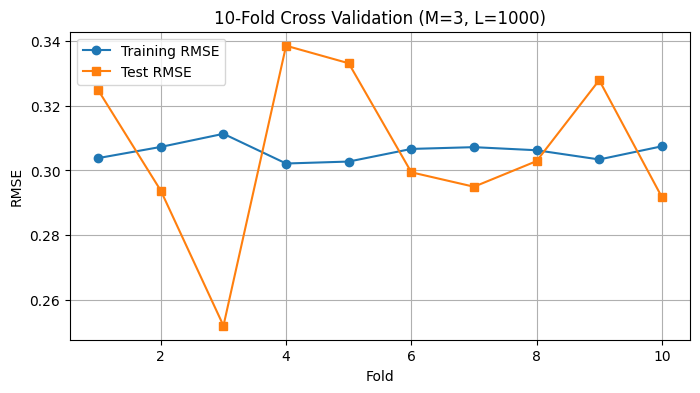

Avg Training RMSE: 0.3058261605775554
Avg Test RMSE: 0.30591891918178904


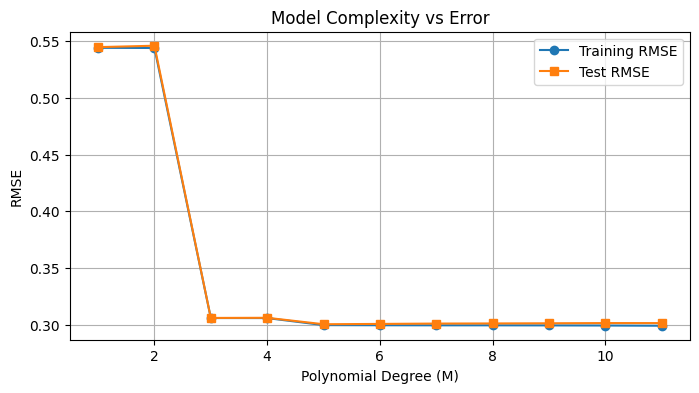

In [10]:
from sklearn.model_selection import KFold
# ----------------------------
# Helper functions
# ----------------------------
def design_matrix(t, degree):
    """Builds polynomial design matrix [1, t, t^2, ..., t^M]."""
    return np.vstack([t**j for j in range(degree+1)]).T

def mppi_weights(X, y):
    """Compute weights using Moore–Penrose Pseudo-inverse."""
    return np.linalg.pinv(X) @ y

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# ----------------------------
# 1 & 2. MPPI with L=100, M=3
# ----------------------------
L = 100
sigma2 = 0.09
M = 3
rng = np.random.default_rng(42)

t_train = np.linspace(0, 1, L)
y_true_train = np.sin(2 * np.pi * t_train)
y_train = y_true_train + rng.normal(0, np.sqrt(sigma2), L)

X = design_matrix(t_train, M)
W = mppi_weights(X, y_train)

# Evaluate on fine grid
t_test = np.arange(0, 1.01, 0.01)
X_test = design_matrix(t_test, M)
y_hat = X_test @ W
y_true = np.sin(2 * np.pi * t_test)

plt.figure(figsize=(8,4))
plt.plot(t_test, y_true, label="True y(t)=sin(2πt)")
plt.plot(t_test, y_hat, label="MPPI polynomial (M=3)")
plt.scatter(t_train, y_train, s=15, alpha=0.6, label="Training samples")
plt.xlabel("t"); plt.ylabel("y")
plt.title("MPPI vs True Function")
plt.legend(); plt.grid(True); plt.show()

print("Weights from MPPI:", np.round(W, 4))
print("Training RMSE (L=100):", rmse(y_train, X@W))

# ----------------------------
# 3 & 4. Cross-validation with L=1000
# ----------------------------
L = 1000
t_all = np.linspace(0, 1, L)
y_true_all = np.sin(2 * np.pi * t_all)
y_all = y_true_all + rng.normal(0, np.sqrt(sigma2), L)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_rmse, test_rmse = [], []

for train_idx, test_idx in kf.split(t_all):
    X_train, X_test = design_matrix(t_all[train_idx], M), design_matrix(t_all[test_idx], M)
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    
    W = mppi_weights(X_train, y_train)
    train_rmse.append(rmse(y_train, X_train @ W))
    test_rmse.append(rmse(y_test, X_test @ W))

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), train_rmse, 'o-', label="Training RMSE")
plt.plot(range(1, 11), test_rmse, 's-', label="Test RMSE")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("10-Fold Cross Validation (M=3, L=1000)")
plt.legend(); plt.grid(True); plt.show()

print("Avg Training RMSE:", np.mean(train_rmse))
print("Avg Test RMSE:", np.mean(test_rmse))

# ----------------------------
# 5. Model selection: RMSE vs polynomial degree
# ----------------------------
degrees = range(1, 12)
train_errors, test_errors = [], []

for M in degrees:
    fold_train_rmse, fold_test_rmse = [], []
    for train_idx, test_idx in kf.split(t_all):
        X_train, X_test = design_matrix(t_all[train_idx], M), design_matrix(t_all[test_idx], M)
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        W = mppi_weights(X_train, y_train)
        fold_train_rmse.append(rmse(y_train, X_train @ W))
        fold_test_rmse.append(rmse(y_test, X_test @ W))
    train_errors.append(np.mean(fold_train_rmse))
    test_errors.append(np.mean(fold_test_rmse))

plt.figure(figsize=(8,4))
plt.plot(degrees, train_errors, 'o-', label="Training RMSE")
plt.plot(degrees, test_errors, 's-', label="Test RMSE")
plt.xlabel("Polynomial Degree (M)")
plt.ylabel("RMSE")
plt.title("Model Complexity vs Error")
plt.legend(); plt.grid(True); plt.show()